In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("grassknoted/asl-alphabet")

print("Path to dataset files:", path)


100%|██████████| 1.03G/1.03G [00:50<00:00, 21.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1


In [ ]:
import os
print(os.listdir(path))


['asl_alphabet_train', 'asl_alphabet_test']


In [ ]:
from pathlib import Path

data_dir = Path(path) / "asl_alphabet_train" / "asl_alphabet_train"
print(list(data_dir.iterdir())[:5])

[PosixPath('/root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1/asl_alphabet_train/asl_alphabet_train/Z'), PosixPath('/root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1/asl_alphabet_train/asl_alphabet_train/M'), PosixPath('/root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1/asl_alphabet_train/asl_alphabet_train/B'), PosixPath('/root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1/asl_alphabet_train/asl_alphabet_train/P'), PosixPath('/root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1/asl_alphabet_train/asl_alphabet_train/I')]


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm # a progress bar library. It wraps around your loop and shows you a live progress bar in the output

!pip install mediapipe
import mediapipe as mp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 914.7 kB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [ ]:
# Corrected path
data_dir = Path(path) / "asl_alphabet_train" / "asl_alphabet_train"
DATASET_PATH = str(data_dir)
OUTPUT_CSV = "landmarks_dataset.csv"


In [ ]:
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request

In [ ]:
# Download the hand landmarker model
urllib.request.urlretrieve(
    "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task",
    "hand_landmarker.task"
)


('hand_landmarker.task', <http.client.HTTPMessage at 0x7ae15555a300>)

In [ ]:
# Setup
base_options = python.BaseOptions(model_asset_path="hand_landmarker.task") #this point to the file downloaded, that is the actual brain.

options = vision.HandLandmarkerOptions(
    base_options=base_options, #use the model i pointed to
    num_hands=1, #only detect 1 hand per image
    min_hand_detection_confidence=0.3, #how sure it needs to be to say i see a hand
    min_hand_presence_confidence=0.3, #how sure it needs to be to say the hand is still there
    min_tracking_confidence=0.3 #how sure it needs to be when tracking movement

)

detector = vision.HandLandmarker.create_from_options(options) #create the detector with all the options

In [ ]:
DATASET_PATH = str(data_dir)
OUTPUT_CSV = "landmarks_dataset.csv"

In [ ]:
data = [] #will store the 63 numbers landmark for each image -- where mediapipe detect the 21 keypoint on each image and with the x,y,z co-ordinate which makes it 21 x 3 =63
labels = [] #will store the letter for each image
failed = [] #to store the path of the images where mediapipe couldn't detect hand

In [13]:
cols = [f'{coord}_{i}' for i in range(21) for coord in ['x', 'y', 'z']]

for label in tqdm(os.listdir(DATASET_PATH)):
    label_path = os.path.join(DATASET_PATH, label)
    if not os.path.isdir(label_path):
        continue

    for img_file in os.listdir(label_path):
        img_path = os.path.join(label_path, img_file)
        image = cv2.imread(img_path)
        if image is None:
            continue

        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
        result = detector.detect(mp_image)

        if result.hand_landmarks:
            landmarks = result.hand_landmarks[0]
            row = []
            for lm in landmarks:
                row.extend([lm.x, lm.y, lm.z])
            data.append(row)
            labels.append(label);
        else:
            failed.append(img_path)

    # Save after every folder (every ~3000 images)
    if data:
        temp_df = pd.DataFrame(data, columns=cols)
        temp_df["label"] = labels
        write_header = not os.path.exists(OUTPUT_CSV)
        temp_df.to_csv(OUTPUT_CSV, mode='a', header=write_header, index=False)
        data = []
        labels = []
        print(f"Saved folder: {label}")

print(f" Failed detections: {len(failed)}")
print(" Extraction complete!")

  3%|▎         | 1/29 [02:06<58:49, 126.06s/it]

Saved folder: Z


  7%|▋         | 2/29 [04:11<56:28, 125.48s/it]

Saved folder: M


 10%|█         | 3/29 [06:18<54:49, 126.50s/it]

...

Saved folder: U


 97%|█████████▋| 28/29 [59:13<02:11, 131.45s/it]

Saved folder: F


100%|██████████| 29/29 [1:01:25<00:00, 127.10s/it]

Saved folder: R
 Failed detections: 20713
 Extraction complete!


In [19]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/landmarks_dataset.csv")
print(f" Total samples: {len(df)}")
print(f" Classes found: {df['label'].nunique()}")
print(df['label'].value_counts())

 Total samples: 69287
 Classes found: 29
label
Z          4858
F          2907
K          2742
J          2647
S          2640
Y          2637
R          2617
L          2599
V          2596
D          2583
G          2562
U          2557
W          2519
I          2473
H          2472
T          2403
O          2349
E          2344
A          2295
B          2250
X          2237
Q          2229
P          2127
C          2119
del        2042
space      1983
M          1957
N          1529
nothing      14
Name: count, dtype: int64


In [21]:
df = df[df['label'] != 'nothing']
print(f" Samples after dropping nothing: {len(df)}")
print(f" Classes remaining: {df['label'].nunique()}")

 Samples after dropping nothing: 69273
 Classes remaining: 28


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib


In [23]:
# Separate features and labels
X = df.drop("label", axis=1).values
y = df["label"].values

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 55418
Testing samples: 13855


In [24]:
# Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [25]:

# Evaluate
y_pred = model.predict(X_test)
print(f" Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(classification_report(y_test, y_pred))


 Accuracy: 97.64%
              precision    recall  f1-score   support

           A       0.99      0.98      0.98       459
           B       0.98      0.99      0.98       450
           C       0.99      0.99      0.99       424
           D       0.99      0.98      0.98       517
           E       0.97      0.97      0.97       469
           F       0.99      0.99      0.99       582
           G       0.99      0.99      0.99       512
           H       0.99      0.99      0.99       494
           I       0.99      0.97      0.98       495
           J       0.99      0.98      0.98       529
           K       0.99      0.98      0.98       549
           L       0.99      0.99      0.99       520
           M       0.90      0.97      0.93       391
           N       0.95      0.88      0.91       306
           O       0.97      0.98      0.97       470
           P       0.99      0.96      0.97       425
           Q       0.97      0.98      0.97       446
         

In [26]:
# Save the model
joblib.dump(model, "/content/drive/MyDrive/asl_model.pkl")
print("Model saved to Drive!")

Model saved to Drive!


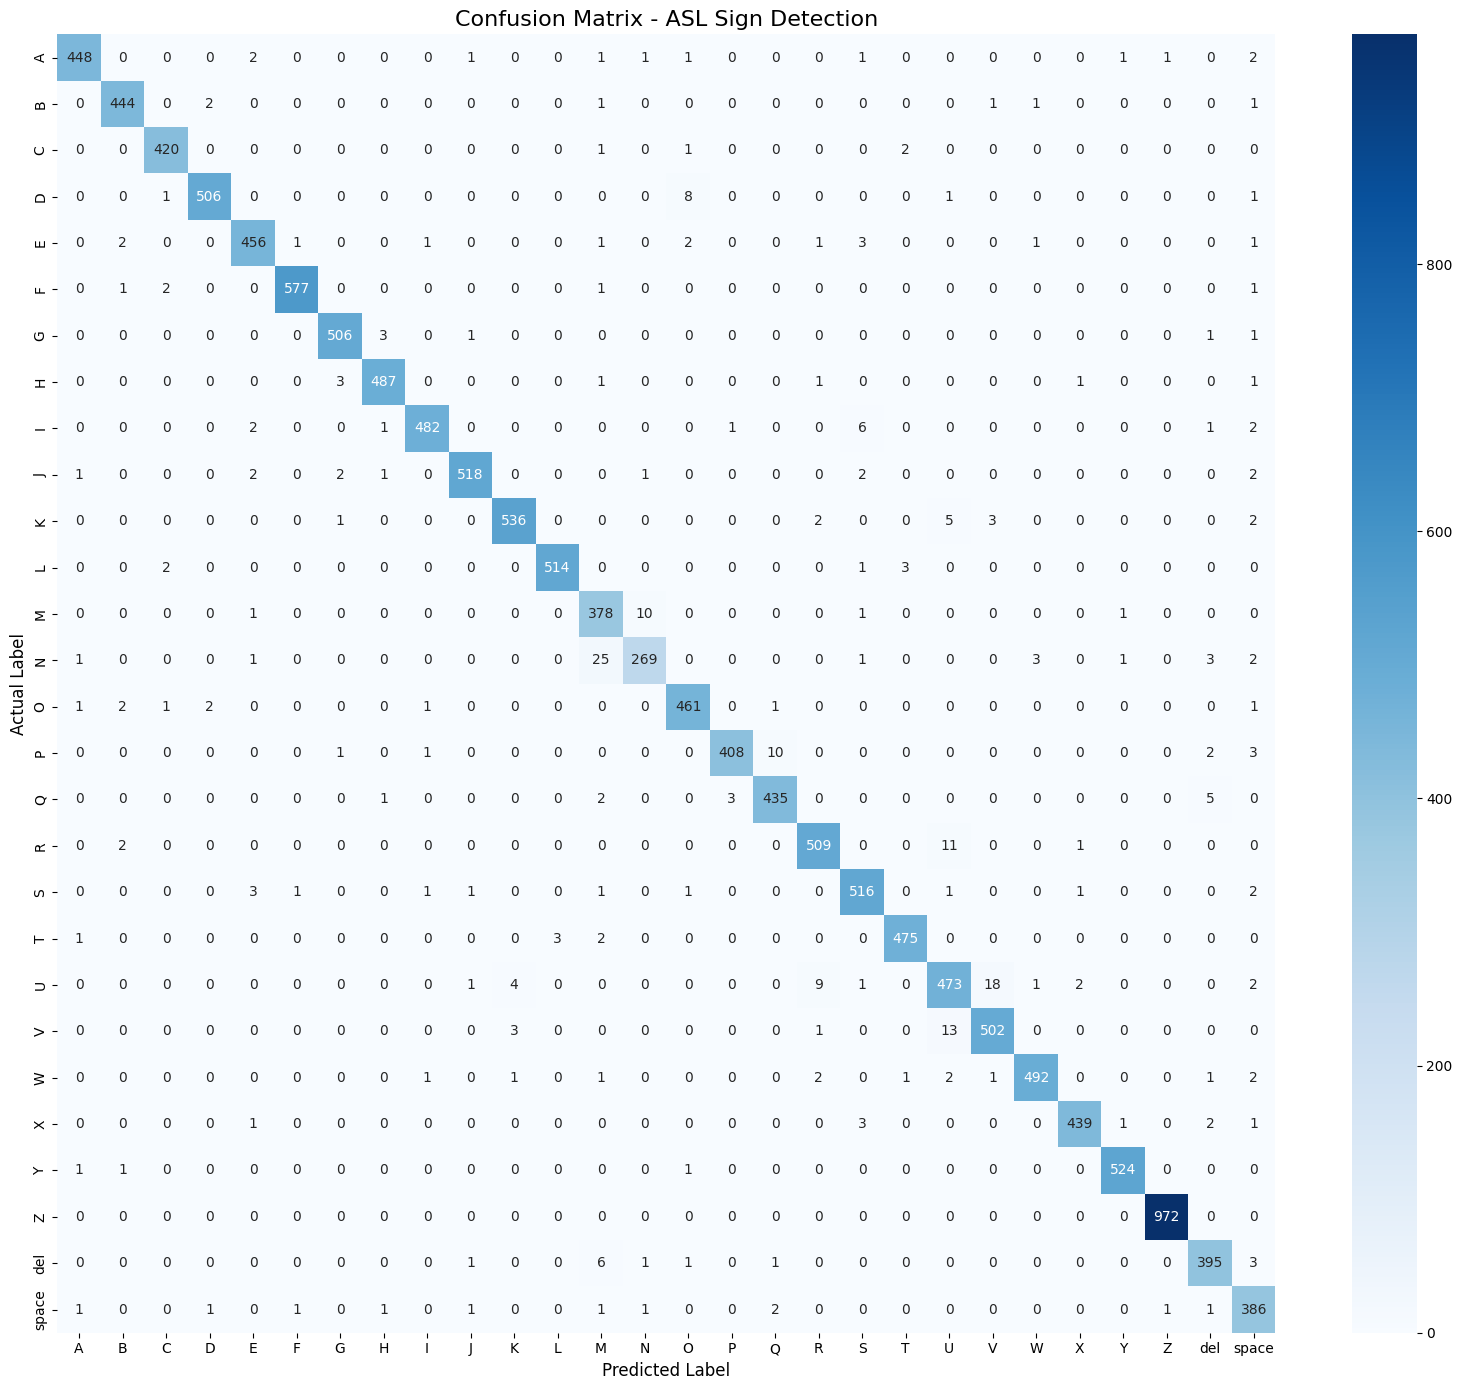

Saved to Drive!


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = sorted(df['label'].unique())

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.title('Confusion Matrix - ASL Sign Detection', fontsize=16)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/confusion_matrix.png", dpi=150)
plt.show()

print("Saved to Drive!")

In [31]:
# Run this in Colab to generate your requirements
!pip freeze > /content/drive/MyDrive/requirements.txt
print("Done!")

✅ Done!
